In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 1000)
pd.options.display.float_format = '{:,.2f}'.format

from sklearn import preprocessing
from scipy.stats import chi2_contingency

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
#import category_encoders as ce

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix

In [2]:
product_target = 'pension_plan'

In [3]:
df = pd.read_csv('data/df_' + product_target + '.csv', sep=';')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# 1. Features Analysis and Transformation before Modelling

In [4]:
df.head()

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,payroll_account,emc_account,debit_card,em_account_p,em_acount,z_months_since_entry,z_pct_months_active,z_partition_segment_changed,z_segment_mode,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,y
0,1000028,2018-01-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0,0,0,0,0.00,0,0,1,0,1,12.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
1,1000028,2018-02-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0,0,0,0,0.00,0,0,1,0,1,13.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
2,1000028,2018-03-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0,0,0,0,0.00,0,0,1,0,1,14.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
3,1000028,2018-04-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0,0,0,0,0.00,0,0,1,0,1,15.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
4,1000028,2018-05-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0,0,0,0,0.00,0,0,1,0,1,16.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00


In [5]:
# columnas que borramos de partida:
df.drop(columns=['entry_date','z_segment_mode'], inplace=True)

In [6]:
# localizamos la última partición:
max_partition = df.pk_partition.max()

# 1. la guardamos en otro df para la predicción final
df_last_partition = df[df["pk_partition"]==max_partition] 
# 2. borramos los registros de la última partición porque no sabemos lo que pasa al mes siguiente
df = df[df["pk_partition"]!=max_partition]

## Global functions

### Correlations

In [7]:
def matriz_correlacion_numeric_features(df):
    numeric_df = df.select_dtypes(include=['number'])

    correlation_matrix = numeric_df.corr(method='pearson')

    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Matriz de Correlación (Pearson)')
    plt.show()

In [8]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    if min(k-1, r-1) == 0:
        return 0.0 
    return np.sqrt((chi2/n) / (min(k-1, r-1)))

def calculate_cramers_v_matrix(df, columns):
    """
    Calculates Cramér's V matrix for a list of categorical columns in a DataFrame.

    Args:
        df: The input pandas DataFrame.
        columns: A list of column names to calculate the Cramér's V matrix for.

    Returns:
        A pandas DataFrame representing the Cramér's V matrix.
    """
    cramer_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for col1 in columns:
        for col2 in columns:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(
                    df[col1].astype(str), df[col2].astype(str)
                )
    return cramer_matrix

In [9]:
def matriz_correlacion_object_features(dfg,listdf):
  cramer_matrix = calculate_cramers_v_matrix(dfg, listdf)

  plt.figure(figsize=(8,6))
  sns.heatmap(cramer_matrix.astype(float), annot=True, cmap="Blues")
  plt.title("Colinealidad (Cramér's V)")
  plt.show()

### Processing

In [10]:
def group_minor_categories(df, col, threshold):
    """
    Agrupa las categorías poco frecuentes de una columna en 'Other'.
    """
    df[col] = df[col].fillna('Unknown').astype(str)
    value_counts = df[col].value_counts(normalize=True)
    minor_categories = value_counts[value_counts < threshold].index
    df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')

    return df


### Feature Engineering

In [11]:
def frequency_encode(df, features_to_encode, normalize=True):
    """
    Aplica Frequency Encoding a una columna categórica,
    crea una nueva columna '<columna>_freq' y elimina la original.
    """

    for feature in features_to_encode:
        freq_encoding = df[feature].value_counts(normalize=normalize)
        new_column_name = f"{feature}_freq"
        df[new_column_name] = df[feature].map(freq_encoding)
        df.drop(columns=[feature], inplace=True)
        
    return df

In [12]:
def one_hot_encode(df, features_to_encode):
    """
    Applies one-hot encoding to a list of specified features in a DataFrame using scikit-learn.
    """
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded = encoder.fit_transform(df[features_to_encode])
    
    encoded_df = pd.DataFrame(
        encoded, 
        columns=encoder.get_feature_names_out(features_to_encode),
        index=df.index
    )
    
    df = df.drop(columns=features_to_encode)
    df = pd.concat([df, encoded_df], axis=1)

    return df

In [13]:
def normalize_features(df, features_to_normalize):
    """
    Normalizes a list of specified features in a DataFrame to a range between 0 and 1.
    """

    scaler = MinMaxScaler()
    df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])
    
    return df

----------------------------------------------------------

In [14]:
stats = []
for col in df.columns:
    stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))

stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% missing values', '% values in biggest category', 'type'])
stats_df = stats_df.sort_values(by=[ '% values in biggest category','Unique_values'], ascending=[False, True])

In [15]:
filtered_stats_categoricas = stats_df[(stats_df['type'] != 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
17,em_account_pp,1,0.00,100.00,int64
23,em_account_p,2,0.00,100.00,int64
13,mortgage,2,0.00,100.00,int64
12,loans,2,0.00,99.99,int64
28,z_churn_customer_flag,2,0.00,99.75,int64
11,short_term_deposit,2,0.00,99.72,int64
14,funds,2,0.00,99.67,int64
15,securities,2,0.00,99.65,int64
33,y,2,0.00,99.65,float64
18,credit_card,2,0.00,98.96,int64


In [16]:
filtered_stats_categoricas = stats_df[(stats_df['type'] == 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
9,deceased,2,0.00,99.98,object
5,country_id,41,0.00,99.96,object
4,segment,3,0.00,69.02,object
2,entry_channel,67,0.00,56.50,object
7,gender,2,0.00,52.05,object
1,pk_partition,16,0.00,7.97,object


Decisiones:
- Borramos "deceased" por tener el 99% de los registros con el mismo valor
- Borramos "country_id" por tener el 99% de los registros con el mismo. Dejamos el region_code que está relleno cuando el pais es España y hay mas variabilidad.
- "segment" y "gender" OHE 
- "entry_channel" agrupar y luego OHE

In [17]:
df.drop(columns=['deceased','country_id'], inplace=True)

In [ ]:
###### OJO!!! MANTENER PARA LUEGO NO VENDER A MUERTOS (NO PARA PREDECIR)

### 1.0 Correlations

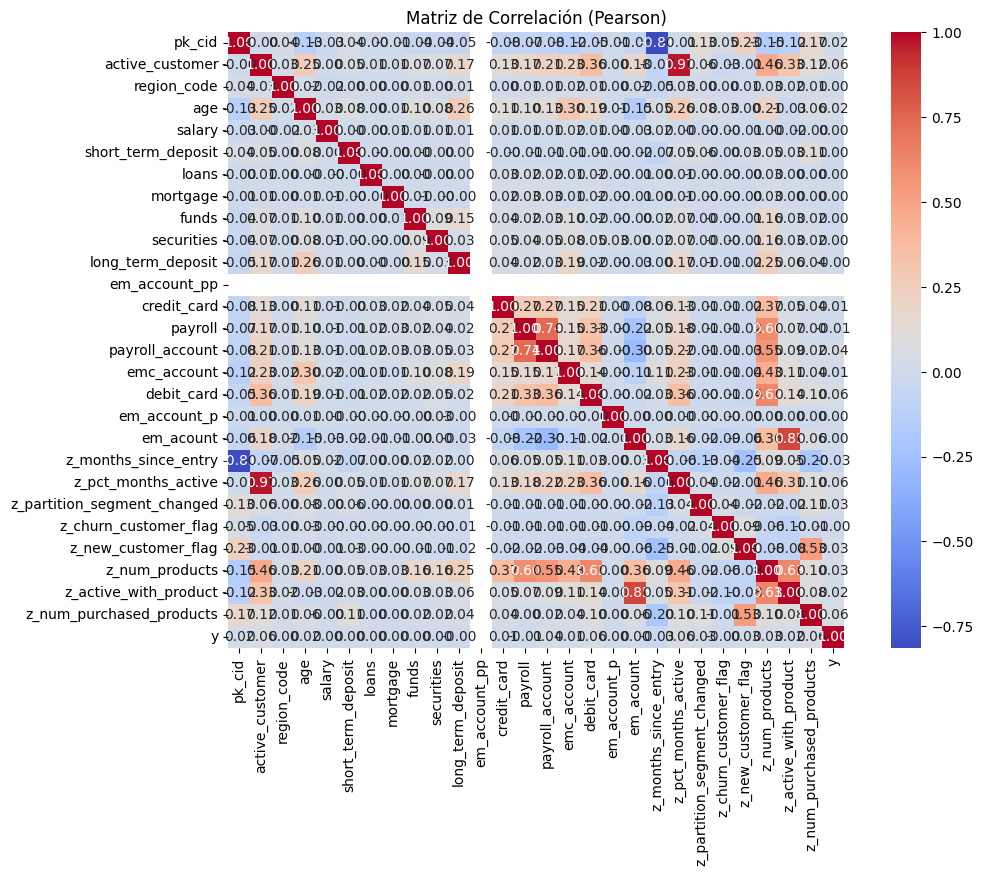

In [18]:
matriz_correlacion_numeric_features(df)

In [19]:
df.em_acount.value_counts(normalize=True)

em_acount
1   0.76
0   0.24
Name: proportion, dtype: float64

In [20]:
# Borramos "z_pct_months_active" por estar al 90% correlada con "active_customer" y "payroll_account" porque es igual que "payroll"
df.drop(columns=['z_pct_months_active', 'payroll_account'], inplace=True)

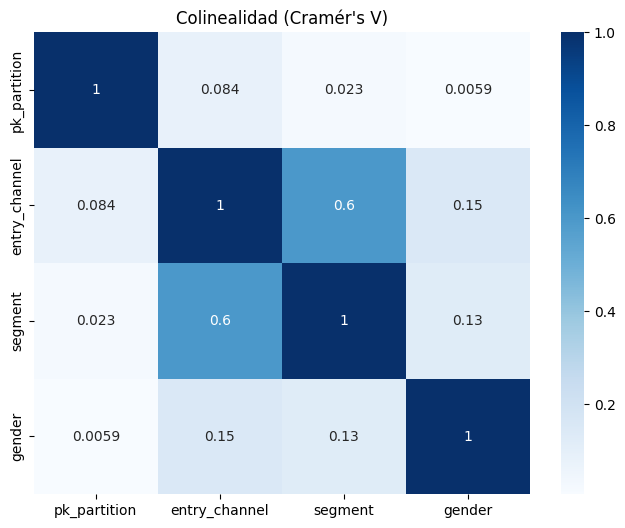

In [21]:
object_cols= df.select_dtypes(exclude=['number']).columns
matriz_correlacion_object_features(df, object_cols)

### 1.1 Fechas - estacionalidad 

In [22]:
df['pk_partition'] = pd.to_datetime(df['pk_partition'])

# Variables temporales
df['month'] = df['pk_partition'].dt.month
df['day_of_year'] = df['pk_partition'].dt.dayofyear
df['weekday'] = df['pk_partition'].dt.weekday  # 0 = lunes, 6 = domingo

# Transformación cíclica (reloj):
# Mes (12 meses)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
# Día del año (365 días)
df['dayofyear_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
# Día de la semana (7 días)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

### 1.2 Encoding

In [23]:
df = group_minor_categories(df, 'entry_channel', 0.01)
df.drop(columns='entry_channel', inplace=True)

df.rename(columns={'entry_channel_grouped':'entry_channel'}, inplace=True)

In [24]:
# df = group_minor_categories(df, 'region_code', 0.005)
# df.drop(columns='region_code', inplace=True)

Mejor no agrupamos la región y le hacemos el Frequency Encoding que consideramos que nos va a aportar más información.

In [25]:
# Frequency Encoding:
freqenc_cols = ['region_code']
df = frequency_encode(df, freqenc_cols)

In [26]:
# One Hot Encoding:
ohe_cols = ['entry_channel','segment','gender']
df = one_hot_encode(df, ohe_cols)

### 1.3 Normalization

In [27]:
normalize_cols = ['age','salary','z_months_since_entry','z_num_products','z_num_purchased_products']

df = normalize_features(df, normalize_cols)

# 2. Modelling

In [28]:
# reordenamos dejando el target al final
col = df.pop("y")
df["y"] = col

In [29]:
df.y.value_counts()

y
0.00    5271114
1.00      18511
Name: count, dtype: int64

### 2.1 Undersampling

In [30]:
df_model = df.copy()

df_pos = df_model[df_model["y"] == 1]
df_neg = df_model[df_model["y"] == 0]

ratio = 3 
df_neg_sample = df_neg.sample(n=len(df_pos)*ratio, random_state=42)

df_balanced = pd.concat([df_pos, df_neg_sample], ignore_index=True).sample(frac=1, random_state=42)

X_bal = df_balanced.drop(columns=["y", "pk_cid", "pk_partition"])
y_bal = df_balanced["y"]

In [31]:
df_balanced.y.value_counts(normalize=True)

y
0.00   0.75
1.00   0.25
Name: proportion, dtype: float64

### 2.2 Model

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

model_us = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    use_label_encoder=False
)

model_us.fit(X_train, y_train)

/Users/martadom/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:33:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### 2.3 Feature Importance

Hacemos este análisis para entender cuales son las variables que más poder tienen en la predicción.

In [33]:
importances = model_us.feature_importances_

In [34]:
feat_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

feat_importances.sort_values(by='importance', ascending=False).head(20)

,feature,importance
0,active_customer,0.35
11,payroll,0.08
13,debit_card,0.06
21,z_active_with_product,0.05
19,z_new_customer_flag,0.04
41,entry_channel_KHQ,0.04
22,z_num_purchased_products,0.04
37,entry_channel_KHE,0.02
8,long_term_deposit,0.02
15,em_acount,0.02


### 2.4 Evaluation

In [35]:
y_pred_train = model_us.predict(X_train)
y_pred_test  = model_us.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))
print("F1 score:", f1_score(y_test, y_pred_test))

Train accuracy: 0.8797670296277539
Test accuracy: 0.8471199945978797
F1 score: 0.6823793490460157


ROC AUC: 0.9043640595967023


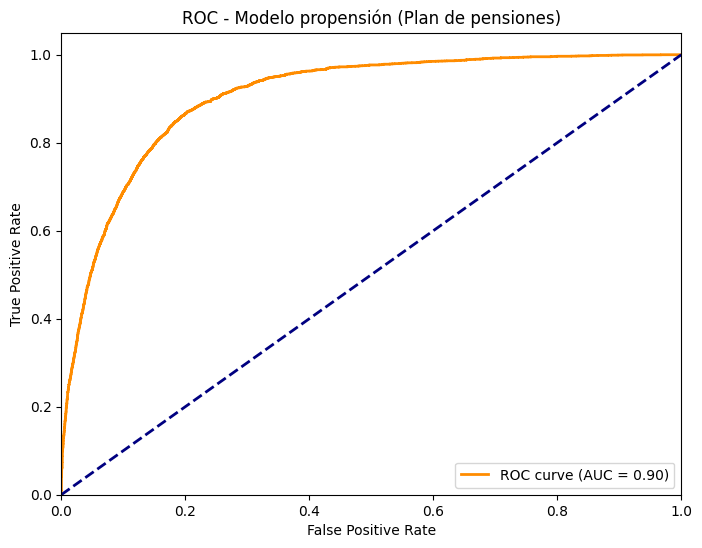

In [36]:
y_prob_test = model_us.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob_test))

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Modelo propensión (Plan de pensiones)')
plt.legend(loc="lower right")
plt.show()